In [2]:
#importing necessary libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
%matplotlib inline

In [3]:
df = pd.DataFrame(load_wine().data,columns=load_wine().feature_names)

In [4]:
df['Class_Labels'] = load_wine().target

In [5]:
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,Class_Labels
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [6]:
#quick overview of dataset
df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,Class_Labels
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  Class

<Axes: >

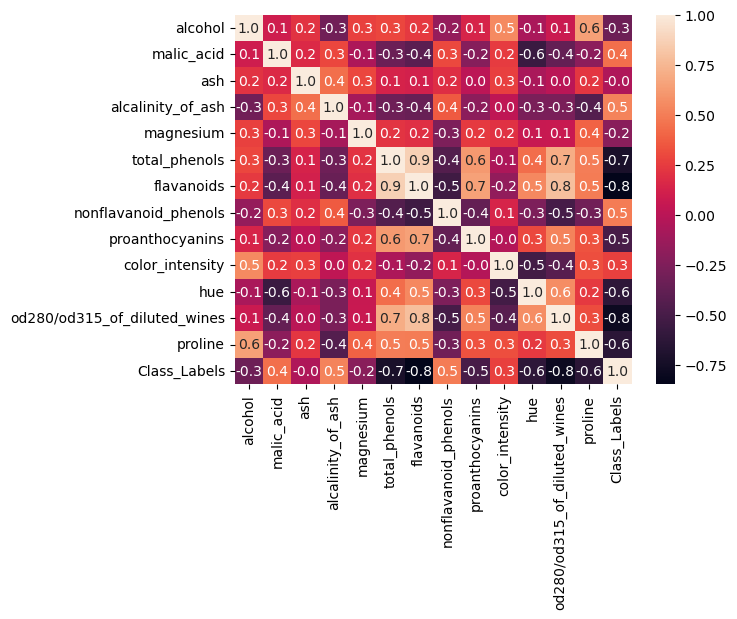

In [8]:
sns.heatmap(df.corr(), annot=True, fmt = '.1f')

In [9]:
#Separating features and target
data = df.values
X = data[:,0:13]
Y = data[:,13]

In [10]:
#Calculate average of each feature for all classes
Y_Data = np.array([np.average(X[:, i][Y==j].astype('float32')) for i in range (X.shape[1])
 for j in (np.unique(Y))])
Y_Data_reshaped = Y_Data.reshape(13, 3)
Y_Data_reshaped = np.swapaxes(Y_Data_reshaped, 0, 1)
X_axis = np.arange(len(df.columns)-1)
width = 0.25 

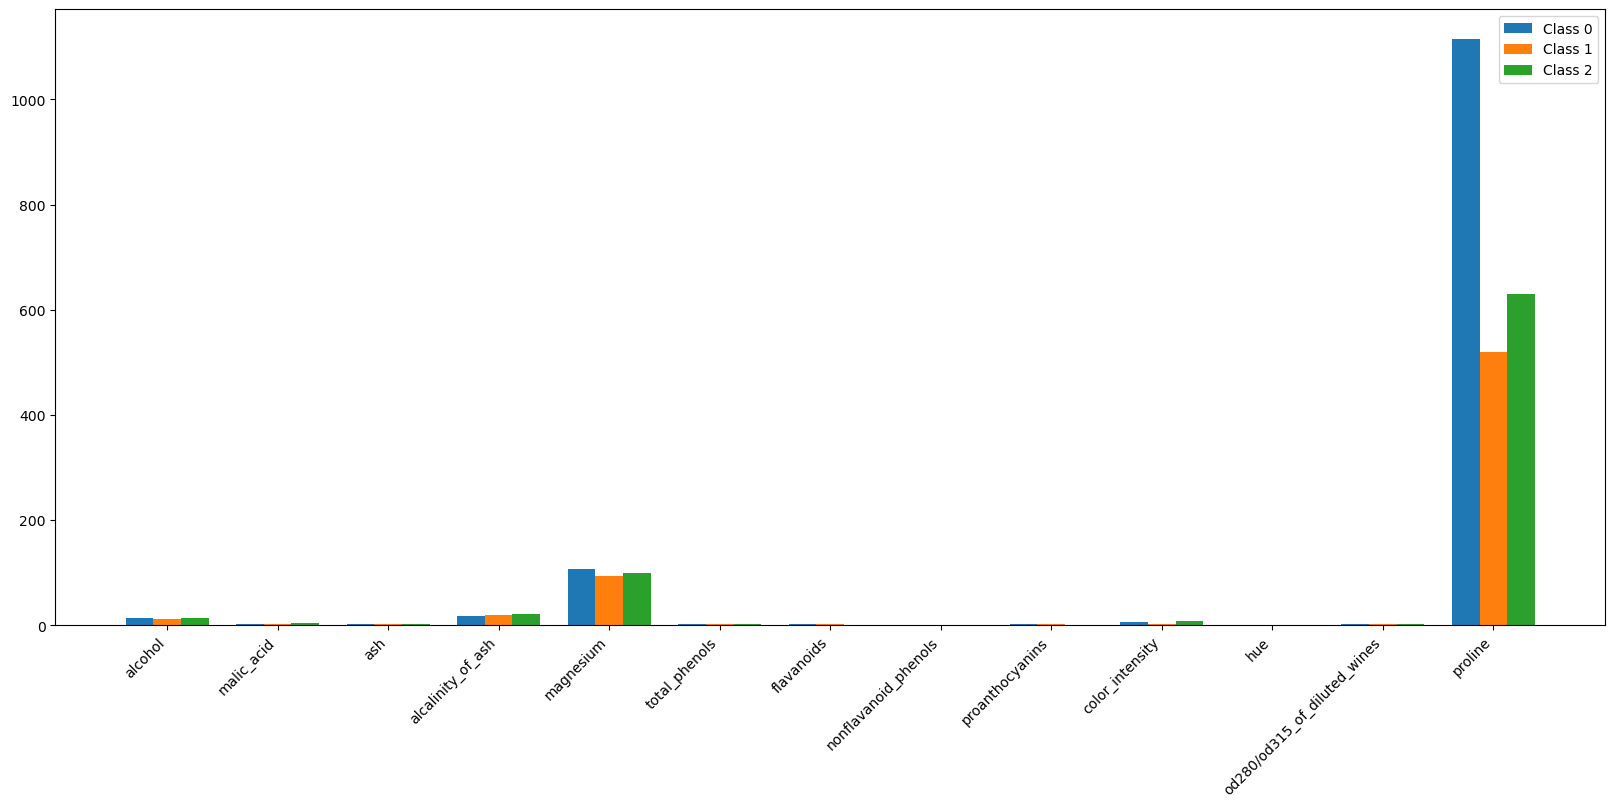

In [11]:
#Plot bar chart
plt.figure(figsize=(20,8))

plt.bar(X_axis, Y_Data_reshaped[0], width, label='Class 0')
plt.bar(X_axis+width, Y_Data_reshaped[1], width, label='Class 1')
plt.bar(X_axis+width*2, Y_Data_reshaped[2], width, label = 'Class 2')

plt.xticks(X_axis + width, df.columns[0:13], rotation = 45, ha='right')
plt.legend()
plt.show()


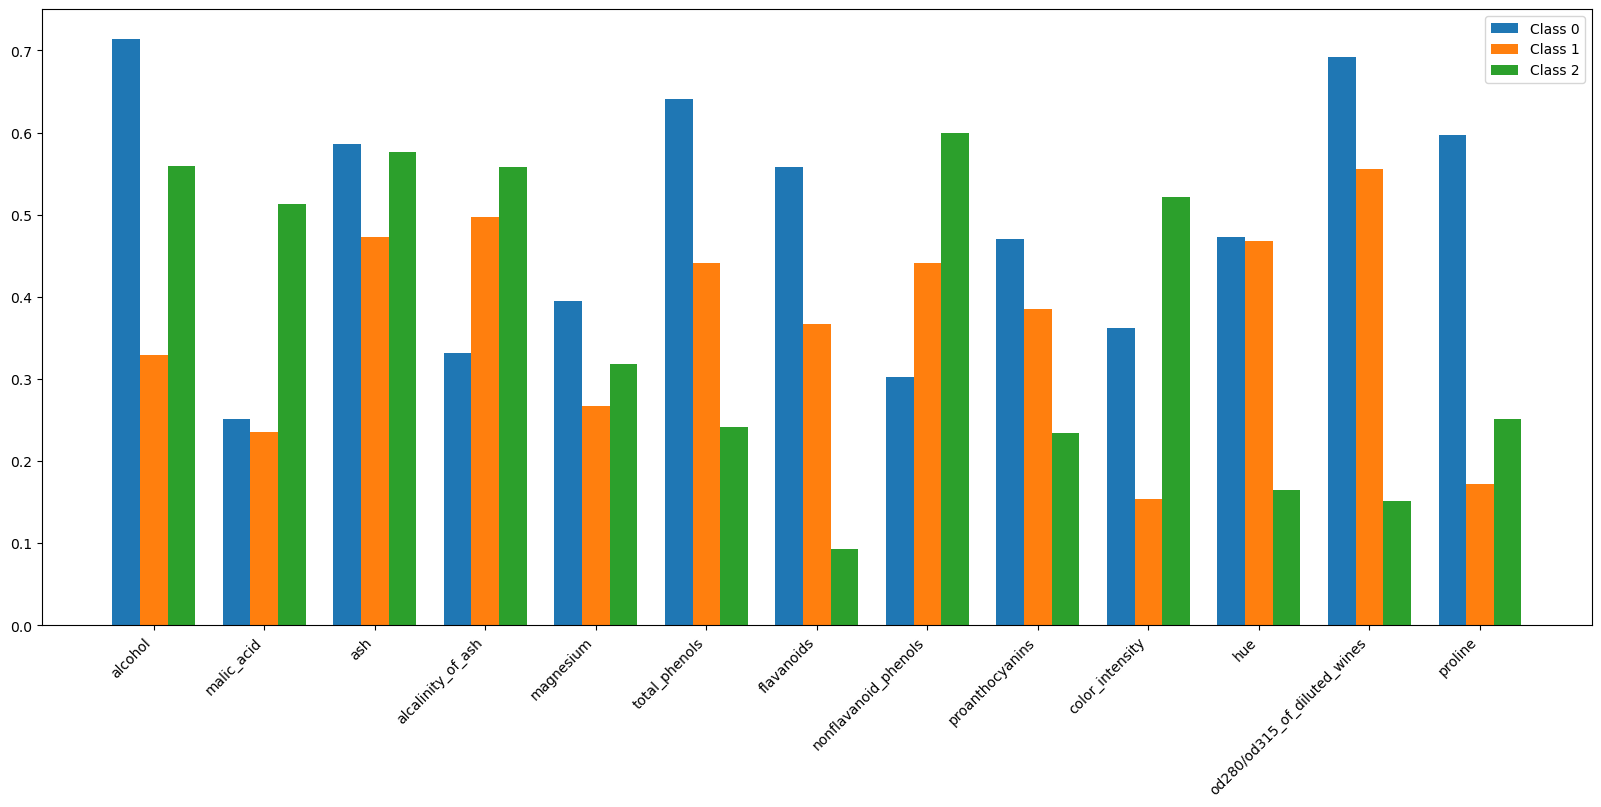

In [12]:
#Need to normalize and scale this graph so that it is readable
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Then redo the averages with X_scaled instead of X
Y_Data = np.array([np.average(X_scaled[:, i][Y==j].astype('float32'))
         for i in range(X_scaled.shape[1])
         for j in (np.unique(Y))])

Y_Data_reshaped = Y_Data.reshape(13, 3)
Y_Data_reshaped = np.swapaxes(Y_Data_reshaped, 0, 1)

#Plot bar chart
plt.figure(figsize=(20,8))

plt.bar(X_axis, Y_Data_reshaped[0], width, label='Class 0')
plt.bar(X_axis+width, Y_Data_reshaped[1], width, label='Class 1')
plt.bar(X_axis+width*2, Y_Data_reshaped[2], width, label = 'Class 2')

plt.xticks(X_axis + width, df.columns[0:13], rotation = 45, ha='right')
plt.legend()
plt.show()

In [31]:
#Train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, Y, test_size=0.2, random_state=10)

In [32]:
#train svc model
from sklearn.svm import SVC
svn = SVC()
svn.fit(X_train, y_train)

SVC()

In [33]:
#Predict from test dataset
predictions = svn.predict(X_test)

#Calculate accuracy
from sklearn.metrics import accuracy_score
accuracy_score(y_test, predictions)

0.9166666666666666

In [34]:
#Delivering detailed classification report
from sklearn.metrics import classification_report
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        10
         1.0       1.00      0.83      0.91        18
         2.0       0.73      1.00      0.84         8

    accuracy                           0.92        36
   macro avg       0.91      0.94      0.92        36
weighted avg       0.94      0.92      0.92        36



In [36]:
# 3 sample wines with 13 features each
# [alcohol, malic_acid, ash, alcalinity_of_ash, magnesium, 
#  total_phenols, flavanoids, nonflavanoid_phenols, proanthocyanins,
#  color_intensity, hue, od280/od315, proline]

X_new = np.array([
    [14.23, 1.71, 2.43, 15.6, 127, 2.80, 3.06, 0.28, 2.29, 5.64, 1.04, 3.92, 1065],
    [12.37, 1.13, 2.16, 19.0, 87,  3.50, 3.10, 0.19, 1.87, 4.45, 1.22, 2.87, 420 ],
    [12.04, 4.30, 2.38, 22.0, 85,  1.65, 0.60, 0.60, 0.96, 2.06, 0.76, 1.74, 480 ]
])

X_new_scaled = scaler.transform(X_new)
prediction = svn.predict(X_new_scaled)
print(f"Prediction of wine class: {prediction}")

Prediction of wine class: [0. 1. 2.]


In [38]:
#Save model
import pickle
with open('SVM.pickle', 'wb') as f:
    pickle.dump(svn, f)
#Load model
with open('SVM.pickle', 'rb') as f:
    model = pickle.load(f)
model.predict(X_new_scaled)

array([0., 1., 2.])